## Initialization Packages

In [1]:
!git clone https://github.com/splunk/cisco-time-series-model.git || echo "Repo already exists"
!curl -LsSf https://astral.sh/uv/install.sh | sh

import os
import sys
from pathlib import Path

os.environ["PATH"] = os.path.expanduser("~/.cargo/bin") + ":" + os.environ["PATH"]

!uv pip install -r cisco-time-series-model/requirements.txt

fatal: destination path 'cisco-time-series-model' already exists and is not an empty directory.
Repo already exists
downloading uv 0.9.26 x86_64-unknown-linux-gnu
no checksums to verify
installing to /home/ubuntu/.local/bin
  uv
  uvx
everything's installed!
Using Python 3.11.14 environment at: venv
Audited 2 packages in 8ms


# Traffic Forecasting

Forecasting internet traffic enables network operators and service providers to proactively manage and optimize their infrastructure. By analyzing historical data, organizations can anticipate demand, prevent congestion, and plan capacity more effectively. Accurate forecasts also support anomaly detection, routing optimization, and maintenance scheduling during low-usage periods, improving efficiency, reducing costs, and maintaining service quality.

---

The dataset used in this laboratory is available under the `data` directory of this repository and as a sample dataset in the Splunk AI Toolkit. It includes a `_time` field spanning **2005-06-07 23:00:00** to **2005-07-29 05:55:00** at **5-minute intervals**, and a `bits_transferred` field representing the volume of data transferred per interval. This structure is well-suited for time series forecasting.

---

This laboratory focuses on sequence-based and attention-based time series models applied to the same internet traffic dataset to ensure consistency.

- **LSTM (Long Short-Term Memory):**  
  A recurrent neural network architecture used to capture temporal dependencies and nonlinear patterns in sequential data.

- **Cisco TSM (Transformer-based model):**  
  A transformer-based approach that uses attention mechanisms to model both short- and long-range temporal dependencies.

Both models are trained on data from the previous month to forecast `bits_transferred` for the next **4 days**, enabling a consistent comparison of their forecasting behavior and performance.


---
# Exploratory Data Analysis

Before training any models, we examine the data visually and statistically to establish a baseline understanding of the time series. This step helps to:

- Understand the overall behavior and variability of the traffic over time  
- Identify trends, recurring patterns (e.g., daily or weekly seasonality), and anomalies  
- Detect potential data quality issues such as missing values or outliers  
- Inform appropriate preprocessing steps and model selection  

In [2]:
# Core data handling and utilities
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt

# Metrics and preprocessing
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

In [3]:
# Load and prepare the dataset
df = pd.read_csv("cisco-time-series-model/1.0-preview/sample_data/internet_traffic.csv")

# Convert timestamp column and set it as index
df["_time"] = pd.to_datetime(df["_time"], unit="s")
df.set_index("_time", inplace=True)

# Inspect structure and sample data
df.info()
df.head()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 10000 entries, 2005-06-07 14:00:00 to 2005-07-12 07:15:00
Data columns (total 1 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   bits_transferred  10000 non-null  float64
dtypes: float64(1)
memory usage: 156.2 KB


,bits_transferred
_time,
2005-06-07 14:00:00,3397.254111
2005-06-07 14:05:00,3538.337298
2005-06-07 14:10:00,3697.843268
2005-06-07 14:15:00,3696.780082
2005-06-07 14:20:00,4370.253163


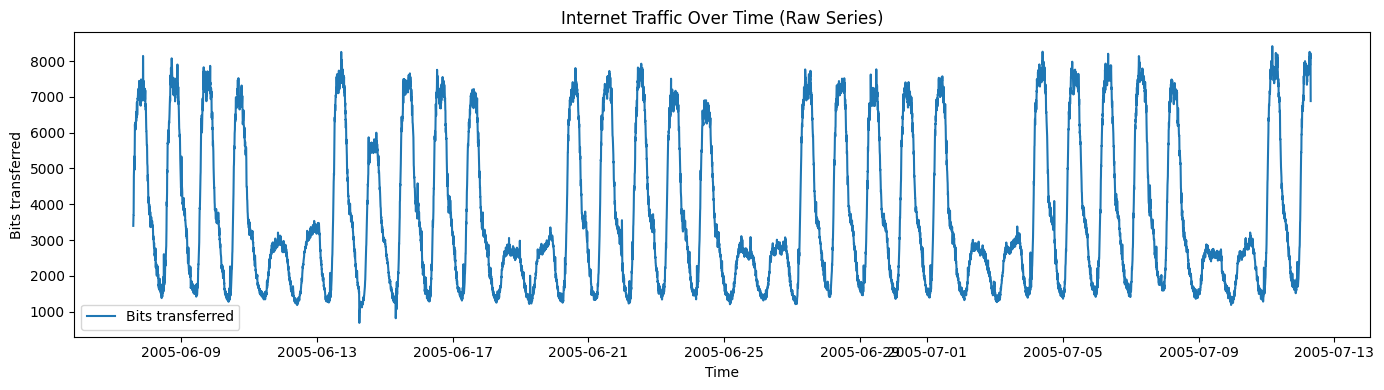

In [4]:
# Visualize raw time series
plt.figure(figsize=(14, 4))
plt.plot(df.index, df["bits_transferred"], label="Bits transferred")
plt.title("Internet Traffic Over Time (Raw Series)")
plt.xlabel("Time")
plt.ylabel("Bits transferred")
plt.legend()
plt.tight_layout()
plt.show()

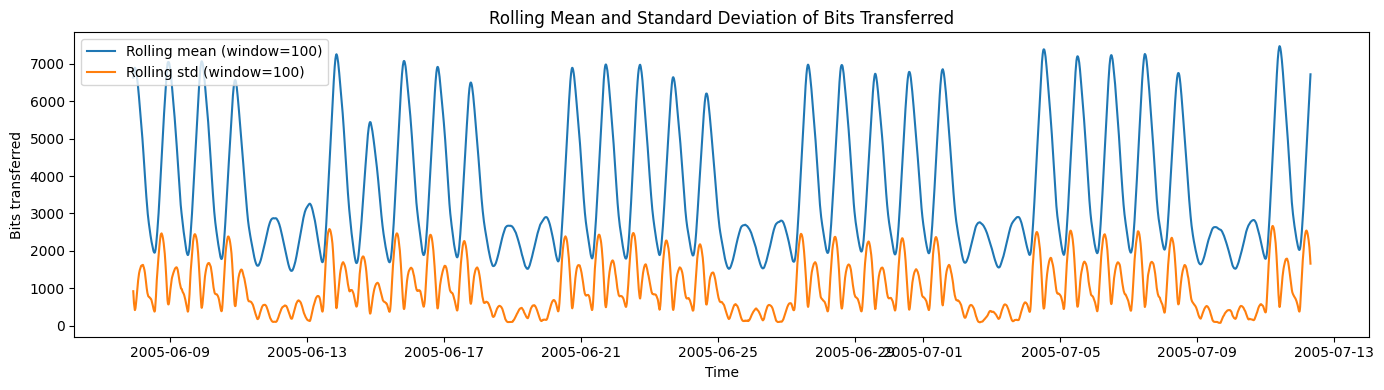

In [5]:
# Visualize rolling statistics
window_size = 100
rolling_mean = df["bits_transferred"].rolling(window_size).mean()
rolling_std = df["bits_transferred"].rolling(window_size).std()

plt.figure(figsize=(14, 4))
plt.plot(df.index, rolling_mean, label=f"Rolling mean (window={window_size})")
plt.plot(df.index, rolling_std, label=f"Rolling std (window={window_size})")
plt.title("Rolling Mean and Standard Deviation of Bits Transferred")
plt.xlabel("Time")
plt.ylabel("Bits transferred")
plt.legend()
plt.tight_layout()
plt.show()

---
# Forecasting with LSTM

In this stage, we implement an **LSTM (Long Short-Term Memory)** model for time series forecasting. LSTM is a type of recurrent neural network designed to learn temporal dependencies and nonlinear patterns in sequential data. By processing the time series step by step, the model retains relevant historical information through an internal memory mechanism.

An LSTM cell uses three main gates to manage information flow:

- **Input Gate**: Determines which new information is stored in memory.
- **Forget Gate**: Decides which past information should be retained or discarded.
- **Output Gate**: Controls what information is passed to the next timestep.

This architecture makes LSTM well suited for:
- Capturing **nonlinear temporal patterns**
- Modeling **long-term dependencies** (e.g., daily or weekly traffic cycles)
- Adapting to **sudden changes** in traffic behavior

In [6]:
# Import libraries for LSTM
import torch
import torch.nn as nn

In [7]:
# Prepare data for LSTM (80/20 split)
df_lstm = df[["bits_transferred"]].copy()

# Compute index for 80% / 20% split
split_index = int(len(df_lstm) * 0.8)

print(f"Split index: {split_index}")

# Train = first 80% of time, Test = last 20% of time
train_data = df_lstm.iloc[:split_index].values
test_data = df_lstm.iloc[split_index:].values

print(f"Train size: {len(train_data)}")
print(f"Test size: {len(test_data)}")

# Normalize the data (LSTM works better with normalized inputs)
scaler = MinMaxScaler(feature_range=(0, 1))
train_scaled = scaler.fit_transform(train_data)
test_scaled = scaler.transform(test_data)

print(f"Data normalized to range: [{train_scaled.min():.3f}, {train_scaled.max():.3f}]")

Split index: 8000
Train size: 8000
Test size: 2000
Data normalized to range: [0.000, 1.000]


In [8]:
# Create sequences for LSTM (use past lookback steps to predict next horizon steps)
def create_sequences_multi(data, lookback=128, horizon=256):
    X, y = [], []
    for i in range(len(data) - lookback - horizon + 1):
        X.append(data[i:i+lookback, 0])
        y.append(data[i+lookback:i+lookback+horizon, 0])
    return np.array(X), np.array(y)

# Set lookback window and forecast horizon
lookback = 128
forecast_horizon = 256   # number of future steps to predict

# Create sequences for training and testing
X_train, y_train = create_sequences_multi(
    train_scaled, lookback=lookback, horizon=forecast_horizon
)
X_test, y_test = create_sequences_multi(
    test_scaled, lookback=lookback, horizon=forecast_horizon
)

# Reshape inputs for LSTM [samples, timesteps, features]
X_train = X_train.reshape((X_train.shape[0], X_train.shape[1], 1))
X_test = X_test.reshape((X_test.shape[0], X_test.shape[1], 1))

print(f"\nReshaped X_train: {X_train.shape}")
print(f"Reshaped X_test: {X_test.shape}")
print(f"y_train shape (multi-step): {y_train.shape}")
print(f"y_test shape (multi-step): {y_test.shape}")


Reshaped X_train: (7617, 128, 1)
Reshaped X_test: (1617, 128, 1)
y_train shape (multi-step): (7617, 256)
y_test shape (multi-step): (1617, 256)


In [9]:
# Define LSTM model architecture (multi-step forecasting)
class LSTMForecaster(nn.Module):
    def __init__(self, input_size=1, hidden_size=32, num_layers=2, dropout=0.2, horizon=12):
        super().__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        self.horizon = horizon
        
        # LSTM layers
        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            dropout=dropout if num_layers > 1 else 0,
            batch_first=True
        )
        
        # Fully connected output layer (predict H future steps)
        self.fc = nn.Linear(hidden_size, horizon)
        
    def forward(self, x):
        # Initialize hidden and cell states
        h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(x.device)
        c0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(x.device)
        
        # Forward propagate LSTM
        out, _ = self.lstm(x, (h0, c0))
        
        # Use the last time step to predict the full horizon
        out = self.fc(out[:, -1, :])
        return out

# Initialize model, loss function, and optimizer
if torch.backends.mps.is_available():
    device = torch.device('mps')
elif torch.cuda.is_available():
    device = torch.device('cuda')
else:
    device = torch.device('cpu')
print(f"Using device: {device}")

lstm_model = LSTMForecaster(
    input_size=1,
    hidden_size=32,
    num_layers=2,
    dropout=0.2,
    horizon=forecast_horizon
).to(device)

criterion = nn.MSELoss()
optimizer = torch.optim.Adam(lstm_model.parameters(), lr=0.001)

print(f"\nModel architecture:")
print(lstm_model)
print(f"\nTotal parameters: {sum(p.numel() for p in lstm_model.parameters())}")

Using device: cuda

Model architecture:
LSTMForecaster(
  (lstm): LSTM(1, 32, num_layers=2, batch_first=True, dropout=0.2)
  (fc): Linear(in_features=32, out_features=256, bias=True)
)

Total parameters: 21376


In [10]:
# Convert numpy arrays to PyTorch tensors and move to device
X_train_tensor = torch.FloatTensor(X_train).to(device)
y_train_tensor = torch.FloatTensor(y_train).to(device)
X_test_tensor = torch.FloatTensor(X_test).to(device)
y_test_tensor = torch.FloatTensor(y_test).to(device)

# Training parameters
num_epochs = 50
batch_size = 64

# Create DataLoader for batching
train_dataset = torch.utils.data.TensorDataset(X_train_tensor, y_train_tensor)
train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

# Training loop
train_losses = []
print("Starting training...")

for epoch in range(num_epochs):
    lstm_model.train()
    epoch_loss = 0
    
    for batch_X, batch_y in train_loader:
        # Forward pass
        outputs = lstm_model(batch_X)
        loss = criterion(outputs, batch_y)
        
        # Backward pass and optimization
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        epoch_loss += loss.item()
    
    avg_loss = epoch_loss / len(train_loader)
    train_losses.append(avg_loss)
    
    # Print progress every 10 epochs
    if (epoch + 1) % 10 == 0:
        print(f'Epoch [{epoch+1}/{num_epochs}], Loss: {avg_loss:.6f}')

print("\nTraining completed!")

Starting training...
Epoch [10/50], Loss: 0.019159
Epoch [20/50], Loss: 0.016071
Epoch [30/50], Loss: 0.031396
Epoch [40/50], Loss: 0.014929
Epoch [50/50], Loss: 0.014566

Training completed!


In [11]:
# Make predictions on train and test sets
lstm_model.eval()
with torch.no_grad():
    train_predictions = lstm_model(X_train_tensor).cpu().numpy()
    test_predictions = lstm_model(X_test_tensor).cpu().numpy()

# Reshape predictions and targets for inverse scaling
# (flatten across forecast horizon)
train_predictions_flat = train_predictions.reshape(-1, 1)
test_predictions_flat = test_predictions.reshape(-1, 1)

y_train_flat = y_train.reshape(-1, 1)
y_test_flat = y_test.reshape(-1, 1)

# Inverse transform to original scale
train_predictions_inv = scaler.inverse_transform(train_predictions_flat)
test_predictions_inv = scaler.inverse_transform(test_predictions_flat)
y_train_actual = scaler.inverse_transform(y_train_flat)
y_test_actual = scaler.inverse_transform(y_test_flat)

# Calculate metrics for LSTM (multi-step)
lstm_mae = mean_absolute_error(y_test_actual, test_predictions_inv)
lstm_mse = mean_squared_error(y_test_actual, test_predictions_inv)
lstm_rmse = np.sqrt(lstm_mse)

# Add performance context
mean_traffic_lstm = y_test_actual.mean()
std_traffic_lstm = y_test_actual.std()
lstm_mae_percentage = (lstm_mae / mean_traffic_lstm) * 100
lstm_rmse_percentage = (lstm_rmse / mean_traffic_lstm) * 100

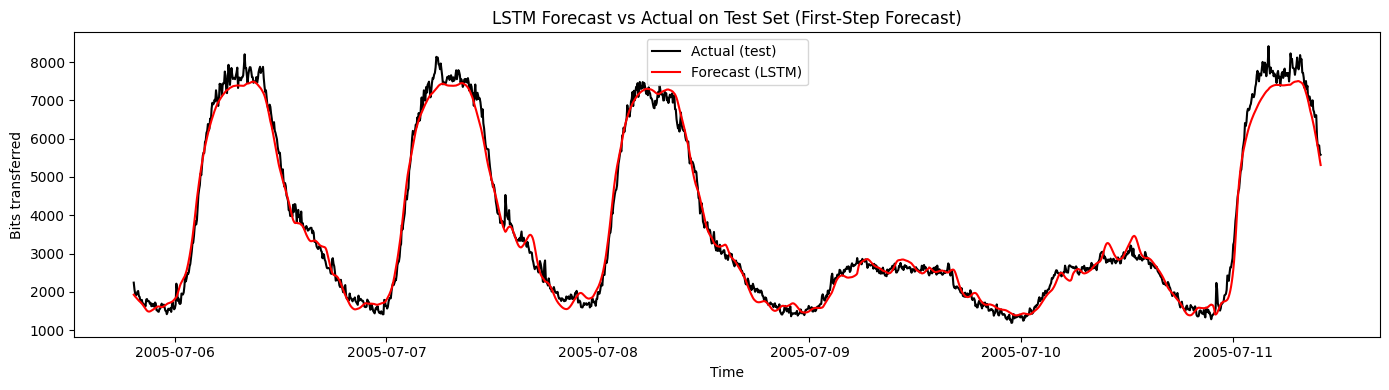

Model           MAE % of Mean        RMSE % of Mean       CV        
----------------------------------------------------------------------
LSTM            18.61                31.90                0.319     


In [22]:
# Visualize only the first forecast step (t+1) for clarity

# Extract first-step predictions from multi-step output
test_predictions_step1 = test_predictions[:, 0].reshape(-1, 1)
y_test_step1 = y_test[:, 0].reshape(-1, 1)

# Inverse transform first-step predictions
test_predictions_step1_inv = scaler.inverse_transform(test_predictions_step1)
y_test_step1_actual = scaler.inverse_transform(y_test_step1)

# Get corresponding timestamps
test_start_idx = split_index + lookback
test_timestamps = df.index[test_start_idx:test_start_idx + len(test_predictions_step1_inv)]

# Create visualization dataframe
df_lstm_viz = pd.DataFrame({
    'timestamp': test_timestamps,
    'actual': y_test_step1_actual.flatten(),
    'predicted': test_predictions_step1_inv.flatten()
})

# Plot LSTM forecast vs actual (first step only)
plt.figure(figsize=(14, 4))
plt.plot(df_lstm_viz['timestamp'], df_lstm_viz['actual'], label='Actual (test)', color='black')
plt.plot(df_lstm_viz['timestamp'], df_lstm_viz['predicted'], label='Forecast (LSTM)', color='red')
plt.title('LSTM Forecast vs Actual on Test Set (First-Step Forecast)')
plt.xlabel('Time')
plt.ylabel('Bits transferred')
plt.legend()
plt.tight_layout()
plt.show()

# Summary table of LSTM results
print(f"{'='*70}")
print(f"{'Model':<15} {'MAE % of Mean':<20} {'RMSE % of Mean':<20} {'CV':<10}")
print(f"{'-'*70}")
print(
    f"{'LSTM':<15} "
    f"{lstm_mae_percentage:<20.2f} "
    f"{lstm_rmse_percentage:<20.2f} "
    f"{(lstm_rmse / mean_traffic_lstm):<10.3f}"
)
print(f"{'='*70}")


---
# Forecasting with Cisco Time Series Model (TSM)

In this section, we introduce **Cisco Time Series Model (TSM)**, a **Transformer-based time series forecasting model** designed to capture complex temporal patterns using attention mechanisms. Unlike LSTM, which processes sequences sequentially, Cisco TSM analyzes the entire historical window simultaneously, allowing it to model both short-term variations and long-range dependencies more effectively.

Cisco TSM is built on the Transformer architecture and benefits from pre-training on diverse time series datasets, enabling strong generalization with limited task-specific tuning. This makes it particularly suitable for dynamic and multi-scale signals such as internet traffic.

Key characteristics of Cisco TSM include:

- **Attention-Based Temporal Modeling**:  
  Self-attention allows the model to assess the relevance of all past timesteps at once, rather than relying on sequential state propagation.

- **Multi-Scale Pattern Recognition**:  
  The model can capture fine-grained fluctuations as well as broader temporal trends within a single representation.

- **Transfer Learning Capabilities**:  
  Pre-training on heterogeneous time series data enables faster convergence and robust performance when applied to new domains.

- **Probabilistic Forecasting Support**:  
  Cisco TSM can produce quantile-based forecasts (e.g., P10, P50, P90), enabling uncertainty-aware analysis and risk-informed decision making.

In this notebook, Cisco TSM is applied using the **same data split, lookback window, normalization strategy, and evaluation metrics** as the LSTM model, ensuring a fair and interpretable architectural comparison.


In [13]:
# Add Cisco Time Series Model repo to PYTHONPATH
repo_root = Path("cisco-time-series-model/1.0-preview").resolve()
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

# Import Cisco Time Series Model libraries
from modeling.cisco_tsm_mr import CiscoTsmMR
from modeling.cisco_tsm_mr import TimesFmCheckpoint, TimesFmHparams

 See https://github.com/google-research/timesfm/blob/master/README.md for updated APIs.
Loaded PyTorch TimesFM, likely because python version is 3.11.14 (main, Oct 10 2025, 08:54:04) [GCC 13.3.0].


/home/ubuntu/venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [14]:
# Configure model hyperparameters
hp = TimesFmHparams(
    num_layers=50,
    use_positional_embedding=False,
    backend="gpu" if (torch.cuda.is_available() or torch.backends.mps.is_available()) else "cpu",
)

# Load model from the Huggingface repo of Cisco Time Series Model
repo_id = "cisco-ai/cisco-time-series-model-1.0-preview"
ckpt = TimesFmCheckpoint(huggingface_repo_id=repo_id)

# Initialize Cisco TSM with multi-resolution support
tsm_model = CiscoTsmMR(
    hparams=hp,
    checkpoint=ckpt,
    use_resolution_embeddings=True,
    use_special_token=True,
)

print(f"Cisco TSM loaded successfully")
print(f"Model architecture: {hp.num_layers} layers")
print(f"Backend: {hp.backend}")

Fetching 7 files: 100%|██████████| 7/7 [00:00<00:00, 75089.84it/s]


Cisco TSM loaded successfully
Model architecture: 50 layers
Backend: gpu


In [15]:
# Prepare data for Cisco TSM (80/20 split)
df_tsm = df[["bits_transferred"]].copy()

# Use the same split index as LSTM
split_index = int(len(df_tsm) * 0.8)

print(f"Split index: {split_index}")
print(f"Train size: {split_index}")
print(f"Test size: {len(df_tsm) - split_index}")

# Context data (historical window)
context_data = df_tsm.iloc[:split_index]["bits_transferred"].values.tolist()

# Forecast horizon (test set length)
forecast_horizon = len(df_tsm) - split_index

print(f"\nForecasting horizon: {forecast_horizon} steps")
print(f"This represents approximately {forecast_horizon * 5 / 60 / 24:.1f} days of 5-minute data")

# Generate forecasts using Cisco TSM
print("\nGenerating forecasts with Cisco TSM...")
tsm_forecasts = tsm_model.forecast([context_data], horizon_len=forecast_horizon)

print("\nForecast completed!")
print(f"Mean forecast shape: {tsm_forecasts[0]['mean'].shape}")
print(f"Available quantiles: {list(tsm_forecasts[0]['quantiles'].keys())}")

Split index: 8000
Train size: 8000
Test size: 2000

Forecasting horizon: 2000 steps
This represents approximately 6.9 days of 5-minute data

Generating forecasts with Cisco TSM...


/home/ubuntu/cisco-time-series-model/1.0-preview/modeling/cisco_tsm_mr.py:373: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at /pytorch/torch/csrc/utils/tensor_new.cpp:253.)
  batch_coarse = torch.as_tensor(coarse_contexts[start:end],  dtype=torch.float32).unsqueeze(-1).to(self._device)



Forecast completed!
Mean forecast shape: (2000,)
Available quantiles: ['0.1', '0.2', '0.3', '0.4', '0.5', '0.6', '0.7', '0.8', '0.9']


In [16]:
# Extract Cisco TSM predictions (mean forecast)
tsm_predictions = tsm_forecasts[0]["mean"]

# Actual test values
actual_test = df_tsm.iloc[split_index:]["bits_transferred"].values

# Evaluation metrics
tsm_mae = mean_absolute_error(actual_test, tsm_predictions)
tsm_mse = mean_squared_error(actual_test, tsm_predictions)
tsm_rmse = np.sqrt(tsm_mse)

# Performance context
mean_traffic_tsm = actual_test.mean()
std_traffic_tsm = actual_test.std()
tsm_mae_percentage = (tsm_mae / mean_traffic_tsm) * 100
tsm_rmse_percentage = (tsm_rmse / mean_traffic_tsm) * 100


print("Cisco TSM Results:")
print(f"MAE as % of mean: {tsm_mae_percentage:.2f}%")
print(f"RMSE as % of mean: {tsm_rmse_percentage:.2f}%")
print(f"Coefficient of Variation (CV): {(tsm_rmse / mean_traffic_tsm):.3f}")


Cisco TSM Results:
MAE as % of mean: 19.04%
RMSE as % of mean: 31.74%
Coefficient of Variation (CV): 0.317


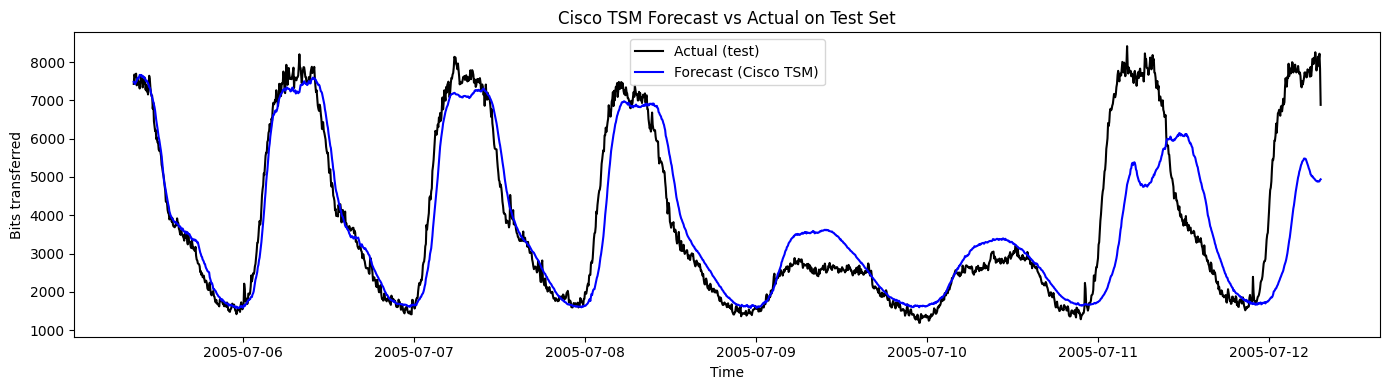

Model           MAE % of Mean        RMSE % of Mean       CV        
----------------------------------------------------------------------
LSTM            18.61                31.90                0.319     
Cisco TSM       19.04                31.74                0.317     


In [17]:
# Get test set timestamps (aligned with forecast horizon)
test_timestamps_tsm = df.index[split_index:split_index + len(tsm_predictions)]

# Create visualization DataFrame
df_tsm_viz = pd.DataFrame({
    "timestamp": test_timestamps_tsm,
    "actual": actual_test,
    "predicted": tsm_predictions
})

# Plot Cisco TSM forecast vs actual
plt.figure(figsize=(14, 4))
plt.plot(df_tsm_viz["timestamp"], df_tsm_viz["actual"], label="Actual (test)", color="black")
plt.plot(df_tsm_viz["timestamp"], df_tsm_viz["predicted"], label="Forecast (Cisco TSM)", color="blue")
plt.title("Cisco TSM Forecast vs Actual on Test Set")
plt.xlabel("Time")
plt.ylabel("Bits transferred")
plt.legend()
plt.tight_layout()
plt.show()

print(f"{'='*70}")
print(f"{'Model':<15} {'MAE % of Mean':<20} {'RMSE % of Mean':<20} {'CV':<10}")
print(f"{'-'*70}")
print(
    f"{'LSTM':<15} "
    f"{lstm_mae_percentage:<20.2f} "
    f"{lstm_rmse_percentage:<20.2f} "
    f"{(lstm_rmse / mean_traffic_lstm):<10.3f}"
)
print(
    f"{'Cisco TSM':<15} "
    f"{tsm_mae_percentage:<20.2f} "
    f"{tsm_rmse_percentage:<20.2f} "
    f"{(tsm_rmse / mean_traffic_tsm):<10.3f}"
)
print(f"{'='*70}")

---
## Key Takeaways

Both models show **very similar performance** when evaluated on the same dataset, split, and metrics, indicating that they capture the main temporal patterns of the signal effectively.

- **LSTM** achieves a slightly lower MAE, suggesting marginally better average point accuracy when trained from scratch on the historical window.

- **Cisco TSM** attains a marginally lower RMSE and coefficient of variation (CV), indicating slightly greater robustness to larger errors and more stable behavior across the forecast horizon.

Overall, the near parity in results suggests that **forecast horizon length and signal volatility** play a larger role in error magnitude than model architecture in this setup. Cisco TSM remains competitive in a zero-shot setting, while LSTM continues to be a strong baseline for this traffic forecasting task.


That´s all Folks !!!